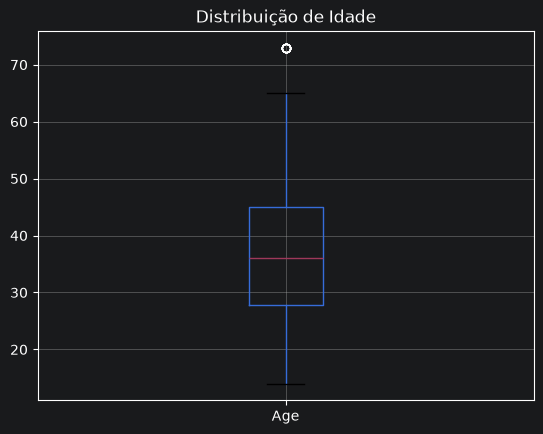

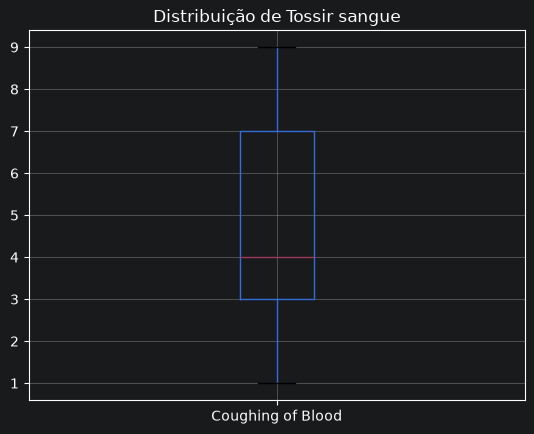




Outliers encontrados:
      Patient Id  Age  Gender  Air Pollution  Alcohol use  Dust Allergy  \
index                                                                     
15          P111   73       1              5            6             6   
126         P211   73       1              5            6             6   
237         P311   73       1              5            6             6   
348         P411   73       1              5            6             6   
459         P511   73       1              5            6             6   
570         P611   73       1              5            6             6   
681         P711   73       1              5            6             6   
792         P811   73       1              5            6             6   
889           P9   73       1              5            6             6   
903         P911   73       1              5            6             6   

       OccuPational Hazards  Genetic Risk  chronic Lung Disease  \
index  

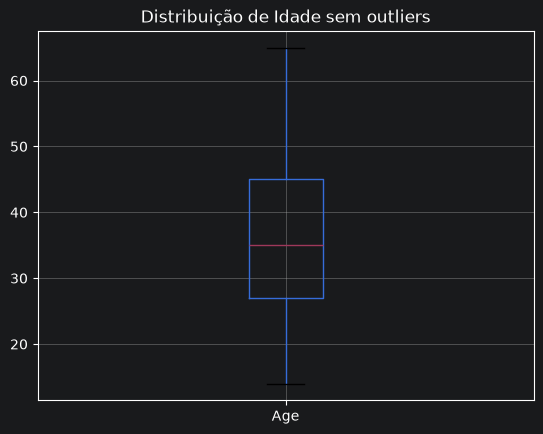

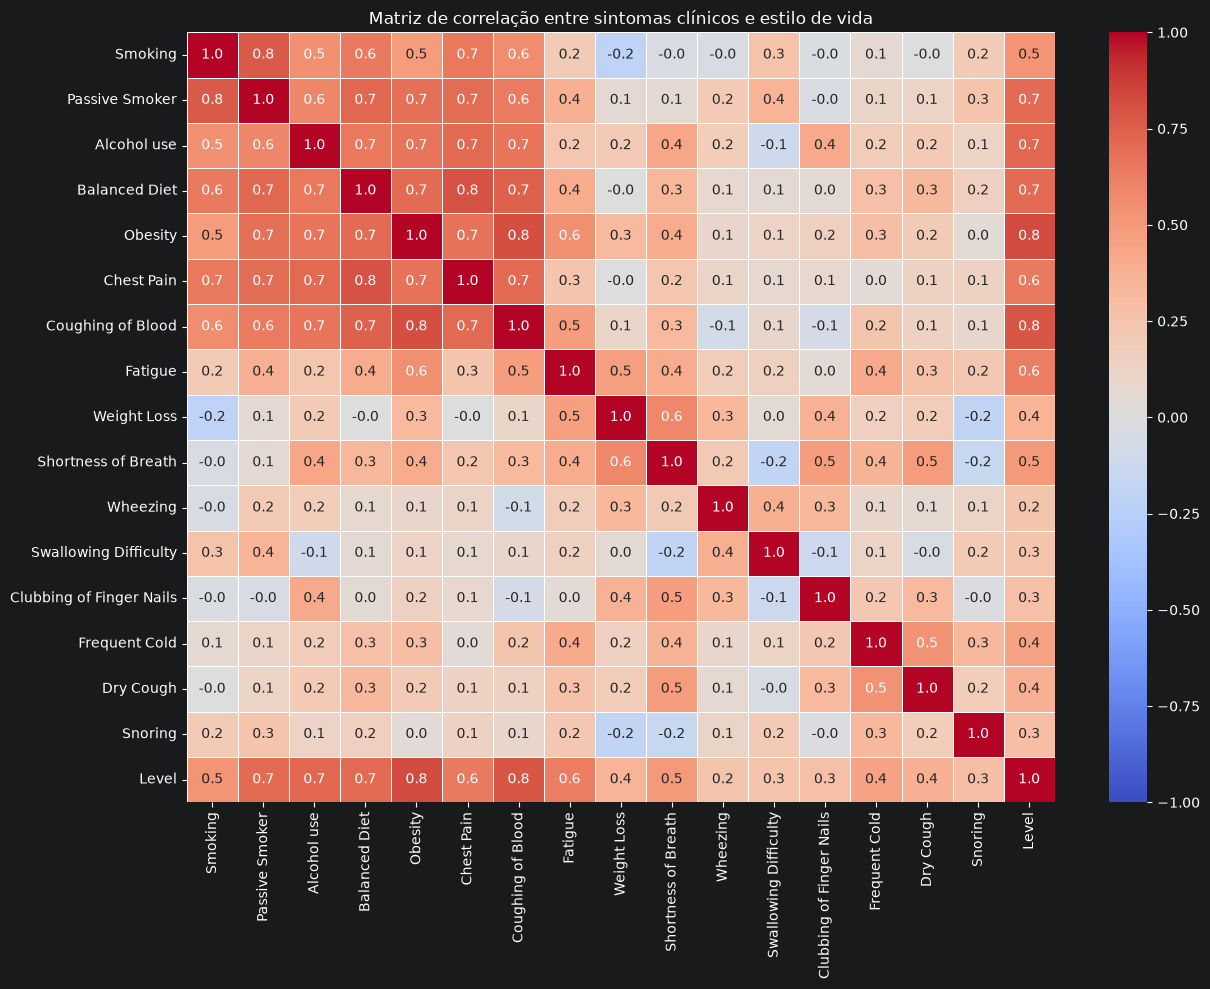

252
285


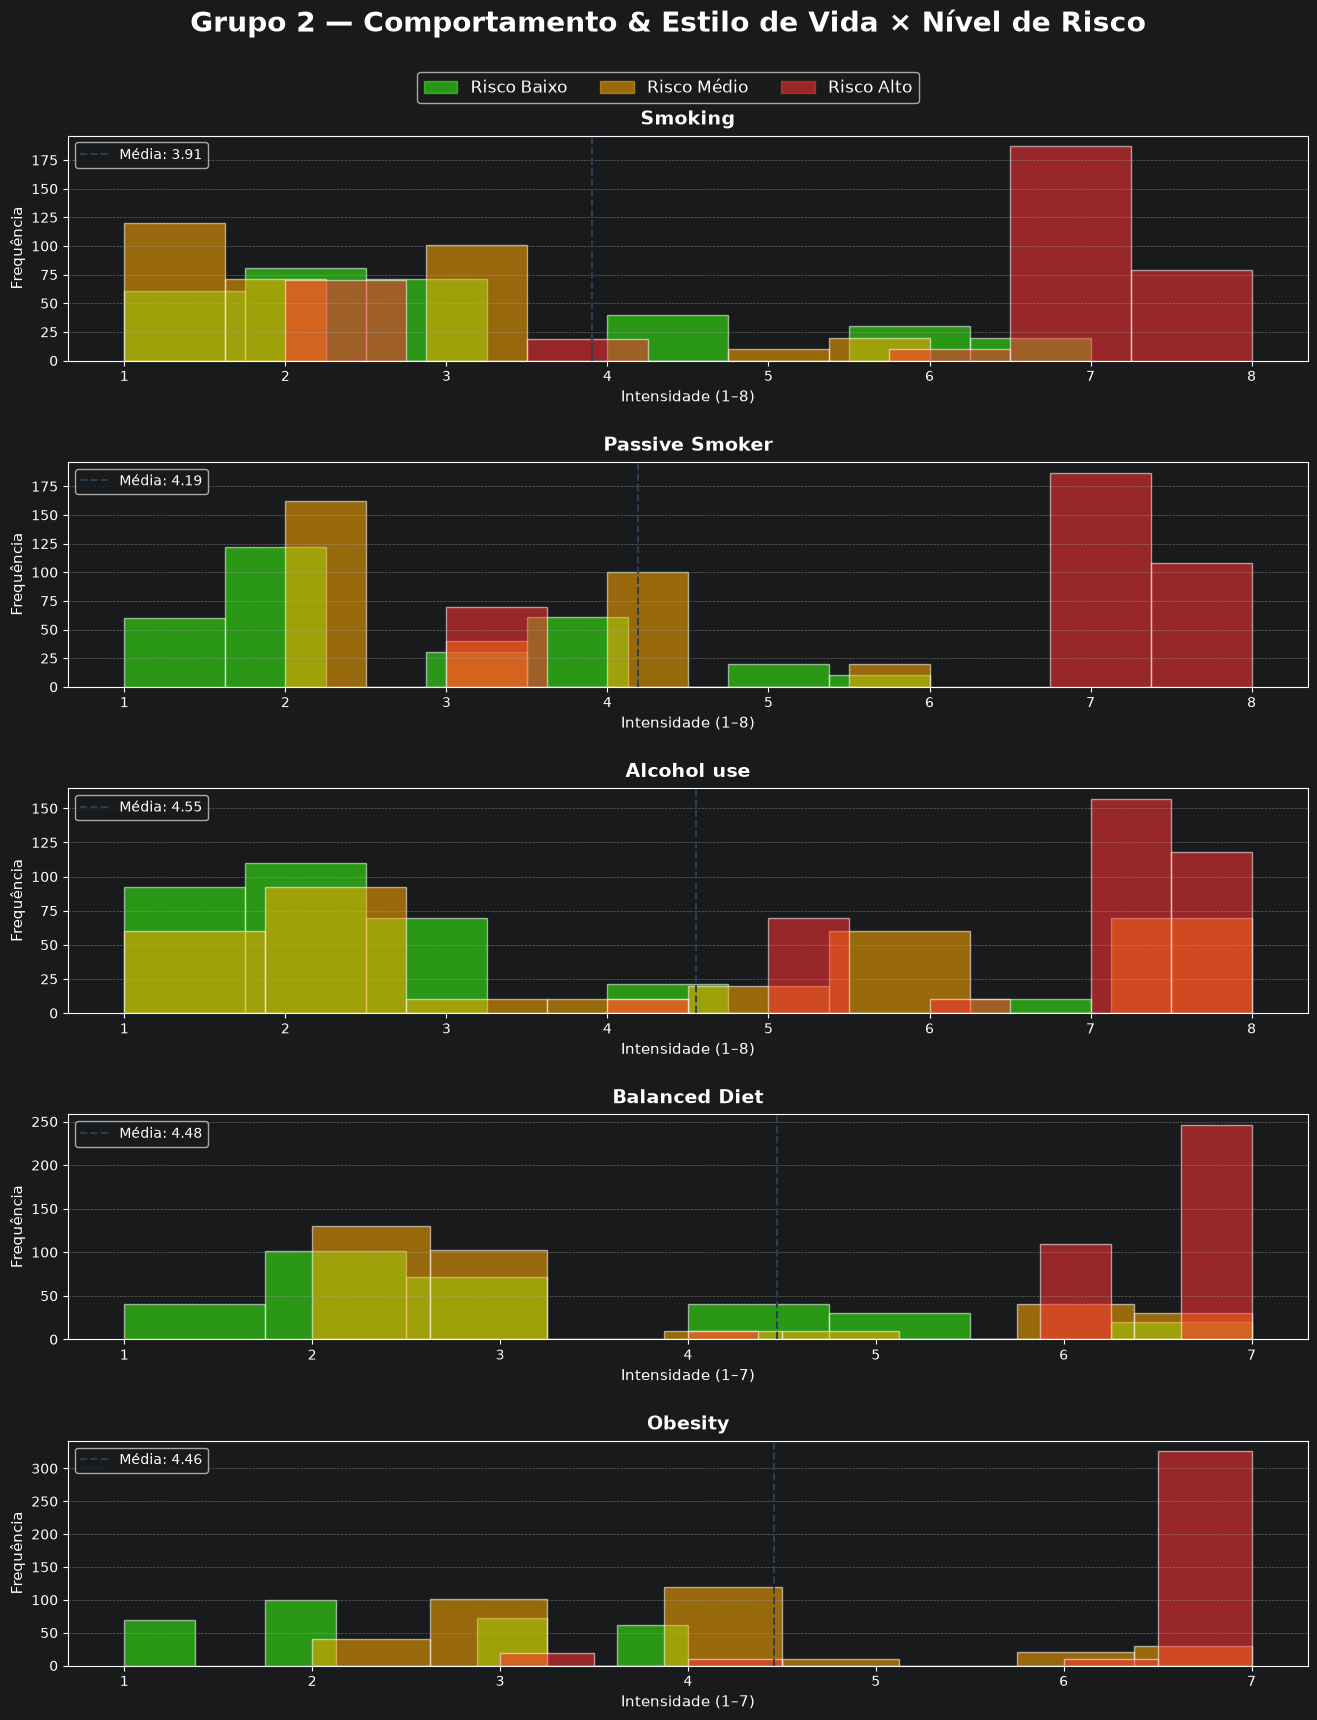

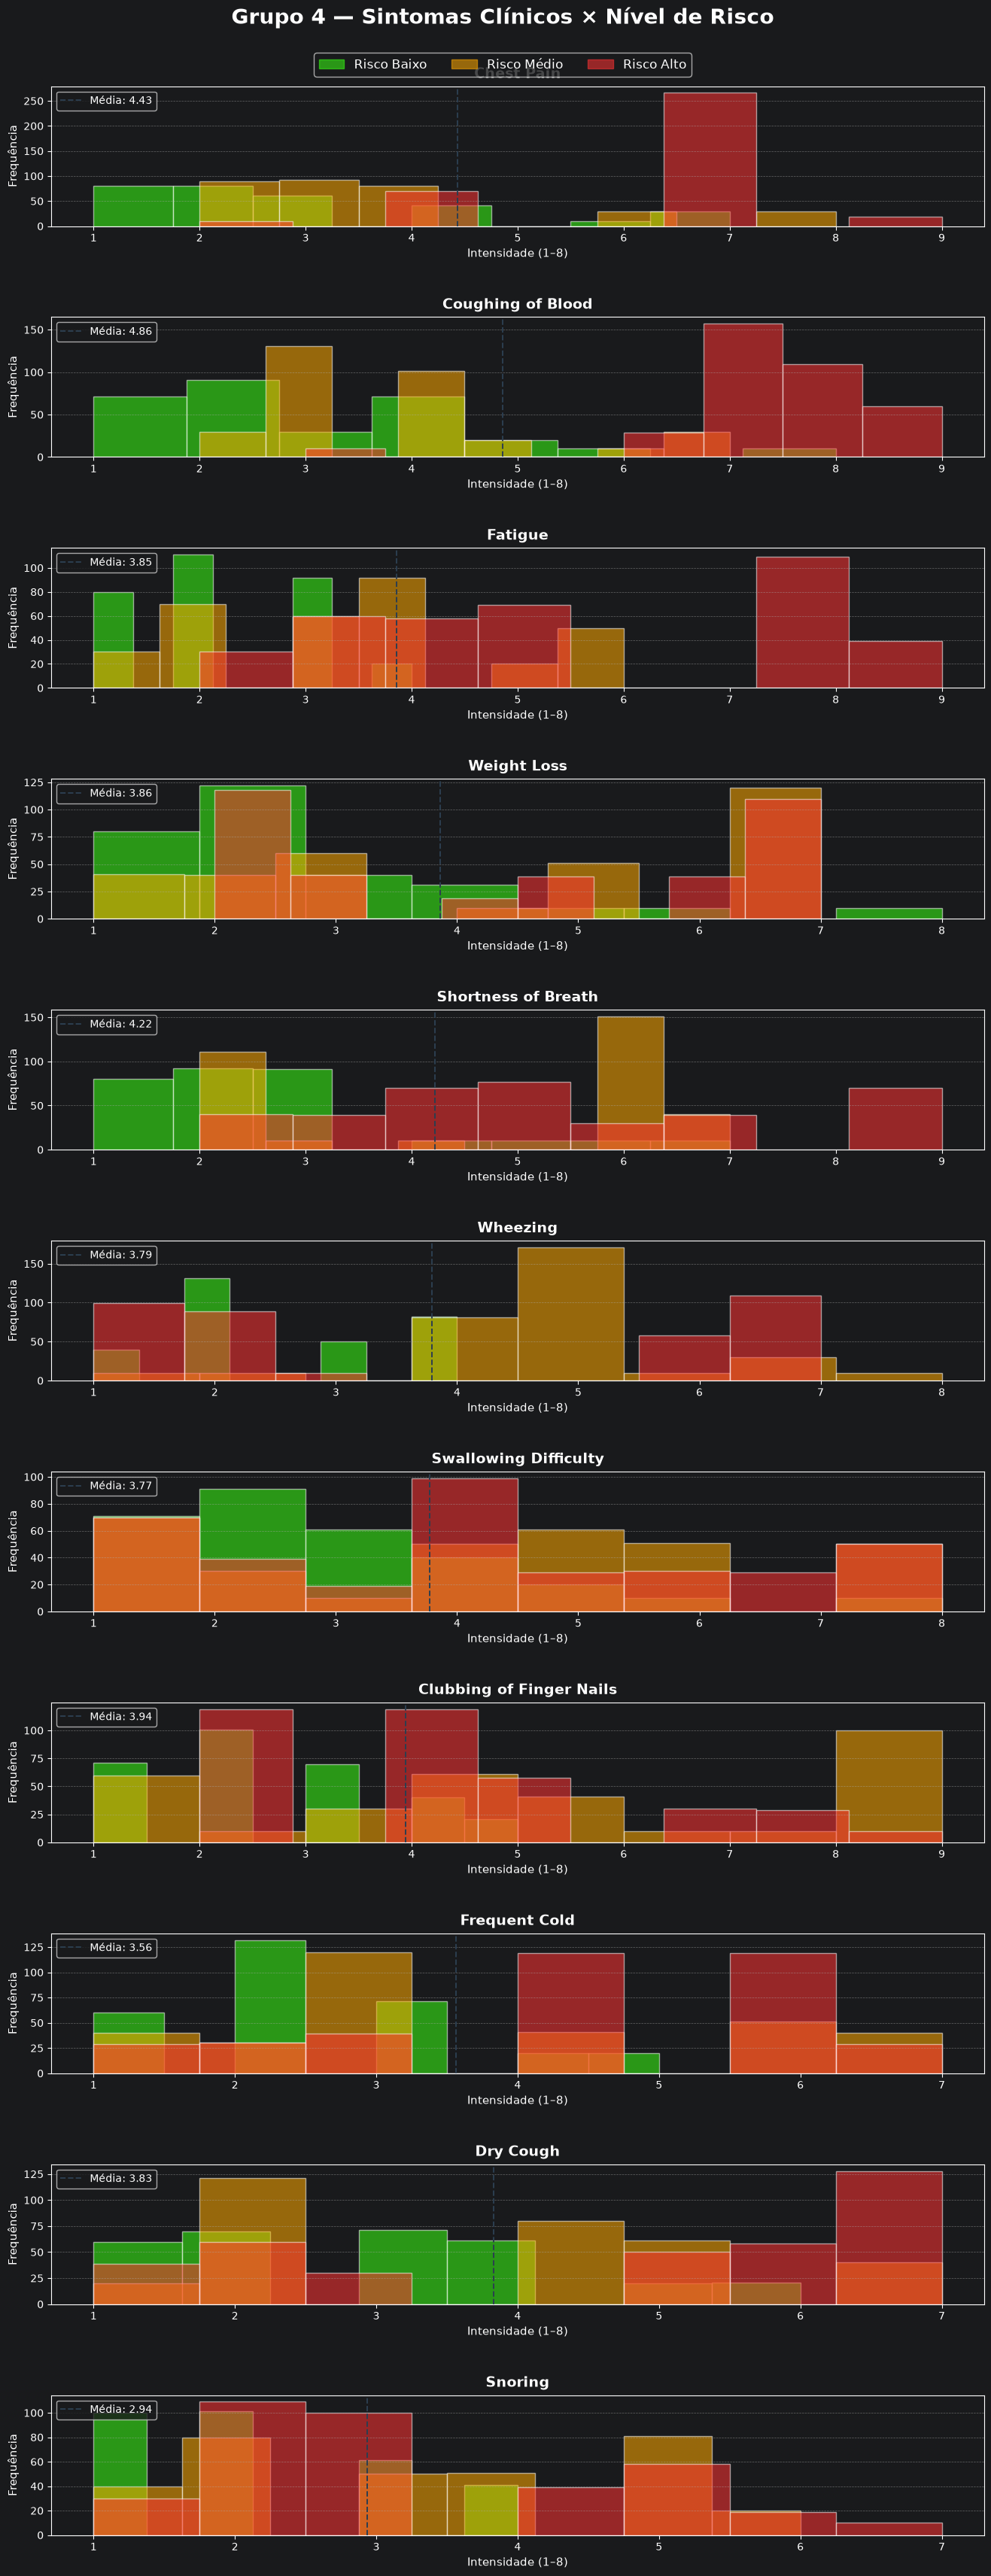

accuracy: 1.0


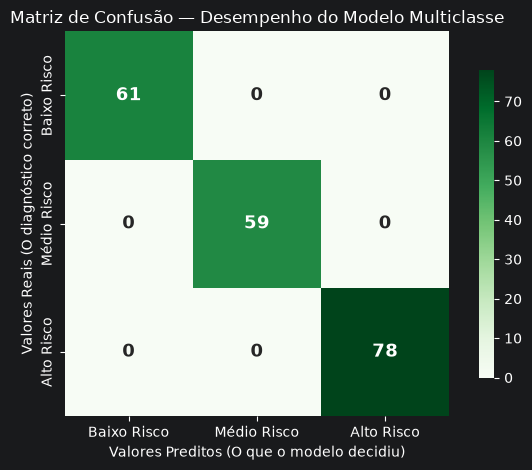

Métricas Gerais do Modelo (Média Macro):
-> Precision: 1.0
-> Recall:    1.0
-> F1-Score:  1.0


['scaler.pkl']

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import average
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import LabelEncoder
from scipy.stats import skew
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score
import joblib


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score,f1_score,roc_curve, roc_auc_score


df_1 = pd.read_csv('Dataset(1).csv', index_col='index')

#df_1.head()
#df_1.info()

#DUPLICADOS - SEM DUPLICADOS
#duplicados = df_1[df_1.duplicated(keep='first')]
#print(duplicados)

#VENDO SE TEM NaN - NÃO TEM NAN
#check_null = pd.isnull(df_1)
#print(check_null) #- Sem nulos. check null retornou false, portanto sem nulos.

#Descobrimos que os registros após 999 são todos preenchidos por zeros. Quando se faz a checagem dos valores nulos eles passam despercebidos.

#REMOVENDO OS ZEROS - TINHA, REGISTROS APOS O 999
df_1 = df_1[df_1['Patient Id'] != '0']

#Transformar level em valor numérico
mapa = {'Low': 0, 'Medium': 1, 'High': 2}
df_1['Level'] = df_1['Level'].map(mapa)

#OUTLIERS
#gráfico dificil de compreender, porem ajudou a achar os valores 0s
#sns.scatterplot(x=range(len(df_1['Age'])), y=df_1['Age'])
#plt.title("Scatter Plot for Age")
#plt.show()

df_1.boxplot(column='Age')
plt.title('Distribuição de Idade')
plt.show()

#Verificando em Coughing of Blood - não tem
df_1.boxplot(column='Coughing of Blood')
plt.title('Distribuição de Tossir sangue')
plt.show()

print("\n\n")

#Vendo os limites superiores, inferiores e quartis
q1 = df_1['Age'].quantile(0.25)
q3 = df_1['Age'].quantile(0.75)
IQR = q3-q1
lower_limit = q1 - 1.5*IQR
upper_limit = q3 + 1.5*IQR
outliers = df_1[(df_1['Age'] < lower_limit) | (df_1['Age'] > upper_limit)]
print(f'Outliers encontrados:\n{outliers}')

#Removendo os outliers
df_sem_outlier = df_1[(df_1['Age'] >= lower_limit) & (df_1['Age'] <= upper_limit)]
#print(len(df_1))
#print(len(df_sem_outlier))
df_1 = df_sem_outlier

df_1.boxplot(column='Age')
plt.title('Distribuição de Idade sem outliers')
plt.show()
#df_1.to_csv("Dataset(1).csv")

#Verificando os parametros
df_1.max()

print("\n\n")

#Matriz de correlação
colunas_selecionadas = ["Smoking", "Passive Smoker", "Alcohol use", "Balanced Diet", "Obesity", "Chest Pain", "Coughing of Blood", "Fatigue", "Weight Loss",
                        "Shortness of Breath", "Wheezing", "Swallowing Difficulty", "Clubbing of Finger Nails", "Frequent Cold", "Dry Cough", "Snoring", "Level"]

matriz = df_1[colunas_selecionadas].corr()
plt.figure(figsize=(14, 10))
sns.heatmap(matriz, annot=True, fmt=".1f", linewidths=.6, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de correlação entre sintomas clínicos e estilo de vida")
plt.savefig('correlação2e3.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

totalh = len(df_1[(df_1['Gender'] == 1) & (df_1['Level'] == 2)])
print(totalh)

totalFumoBebida = len(df_1[(df_1['Smoking'] > 1) & (df_1['Alcohol use'] > 6)])
print(totalFumoBebida)

# Histograma de relação de Level com o Grupo 2
PALETTE_RISK = ['#39ff14', '#ffaa00', '#ff3333']
LABELS_RISK = ['Risco Baixo', 'Risco Médio', 'Risco Alto']

fig, axes = plt.subplots(5, 1, figsize=(16, 18))
fig.suptitle('Grupo 2 — Comportamento & Estilo de Vida × Nível de Risco',
             fontsize=20, fontweight='bold', y=0.97)

G2_VARS = ['Smoking', 'Passive Smoker', 'Alcohol use', 'Balanced Diet', 'Obesity']

axes_flat = axes.flatten()

for ax, var in zip(axes_flat, G2_VARS):
    for lv in [0, 1, 2]:
        ax.hist(df_1[df_1['Level'] == lv][var], bins=8, alpha=0.55,
                color=PALETTE_RISK[lv], edgecolor='white')

    media = df_1[var].mean()
    ax.axvline(media, color='#2c3e50', linestyle='--', linewidth=1.4,
               label=f'Média: {media:.2f}')

    ax.set_title(var, fontsize=14, fontweight='bold', pad=8)

    escala_max = 7 if var in ['Balanced Diet', 'Obesity'] else 8
    ax.set_xlabel(f'Intensidade (1–{escala_max})', fontsize=11)
    ax.set_ylabel('Frequência', fontsize=11)

    ax.legend(loc='upper left', fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

handles_legenda = [plt.Rectangle((0,0),1,1, color=color, alpha=0.55) for color in PALETTE_RISK]
fig.legend(handles_legenda, LABELS_RISK, loc='upper center', bbox_to_anchor=(0.5, 0.94),
           ncol=3, fontsize=12, frameon=True)

plt.subplots_adjust(top=0.90, hspace=0.45, bottom=0.05)
plt.savefig('histograma_grupo_2.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()

print("\n\n")
#Histograma grupo 4
fig, axes = plt.subplots(11, 1, figsize=(16, 35))
fig.suptitle('Grupo 4 — Sintomas Clínicos × Nível de Risco',
             fontsize=20, fontweight='bold', y=0.98) # Ajustado o y para o topo

G4_VARS = [
    'Chest Pain', 'Coughing of Blood', 'Fatigue', 'Weight Loss',
    'Shortness of Breath', 'Wheezing', 'Swallowing Difficulty',
    'Clubbing of Finger Nails', 'Frequent Cold', 'Dry Cough', 'Snoring'
]

axes_flat = axes.flatten()

for ax, var in zip(axes_flat, G4_VARS):
    for lv in [0, 1, 2]:
        ax.hist(df_1[df_1['Level'] == lv][var], bins=8, alpha=0.55,
                color=PALETTE_RISK[lv], edgecolor='white')

    media = df_1[var].mean()
    ax.axvline(media, color='#2c3e50', linestyle='--', linewidth=1.4,
               label=f'Média: {media:.2f}')

    ax.set_title(var, fontsize=14, fontweight='bold', pad=8)

    escala_max = 7 if var in ['Balanced Diet', 'Obesity'] else 8
    ax.set_xlabel(f'Intensidade (1–{escala_max})', fontsize=11)
    ax.set_ylabel('Frequência', fontsize=11)

    ax.legend(loc='upper left', fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

handles_legenda = [plt.Rectangle((0,0),1,1, color=color, alpha=0.55) for color in PALETTE_RISK]
fig.legend(handles_legenda, LABELS_RISK, loc='upper center', bbox_to_anchor=(0.5, 0.965),
           ncol=3, fontsize=12, frameon=True)

plt.subplots_adjust(top=0.95, hspace=0.65, bottom=0.02)
plt.savefig('histograma_grupo_4.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()

#Modelo de previsão regressão
X = df_1.drop(columns=["Level", "Patient Id"])
y = df_1["Level"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
#y_pred - colocar no slide - array conteve 0,1,2 por ter mais de um nível de classificação (low medium high)

y_predprob = model.predict_proba(X_test)

acuracia = accuracy_score(y_test, y_pred)
print(f"accuracy: {round(acuracia,2)}") #O resultado foi 1 normal, já que os dados são sinteticos

#Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            square=True, cbar_kws={"shrink": .8},
            annot_kws={"size": 13, "weight": "bold"},
            xticklabels=['Baixo Risco', 'Médio Risco', 'Alto Risco'],
            yticklabels=['Baixo Risco', 'Médio Risco', 'Alto Risco'])

plt.xlabel('Valores Preditos (O que o modelo decidiu)')
plt.ylabel('Valores Reais (O diagnóstico correto)')
plt.title('Matriz de Confusão — Desempenho do Modelo Multiclasse')

plt.tight_layout()
plt.savefig('confusão2.png', format='png', dpi=300, bbox_inches='tight')

plt.show() #A matriz de confusão ficou 3x3 e o resultado foi excelente

#Métricas gerais
precision = precision_score(y_test, y_pred, average='macro') #macro significa que calcula a precisão, recall e f1 isolada para cada level
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')
print(f"Métricas Gerais do Modelo (Média Macro):")
print(f"-> Precision: {round(precision, 2)}") #A precisão mostra quantos resultados positivos previstos estão realmente corretos.
print(f"-> Recall:    {round(recall, 2)}") #A métrica de recall mede quantos acertos o modelo identifica corretamente.
print(f"-> F1-Score:  {round(f1, 2)}") #Equilibra precisão e recall
joblib.dump(model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")
